<a href="https://colab.research.google.com/github/farrelrassya/Practical-Statistics-for-Data-Scientist-Books/blob/main/PracticalStatisticsChapter7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7: Unsupervised Learning
## *Practical Statistics for Data Scientists* (Bruce, Bruce & Gedeck)

This notebook is a comprehensive companion to Chapter 7, covering the major unsupervised learning techniques: **Principal Components Analysis (PCA)**, **K-Means Clustering**, **Hierarchical Clustering**, **Model-Based Clustering**, and practical considerations around **Scaling and Categorical Variables**.

Unlike supervised learning (Chapters 4--6), where we predict a response from labeled data, **unsupervised learning** finds structure *without* a labeled outcome. The three main goals are:

1. **Dimension reduction** -- compress many variables into fewer components (PCA)
2. **Clustering** -- discover natural groups in the data (K-Means, Hierarchical, GMM)
3. **Exploratory insight** -- understand variable relationships at scale

We work with real S&P 500 stock return data and Lending Club loan data from the book's official repository.

---
**Reference:** [gedeck/practical-statistics-for-data-scientists](https://github.com/gedeck/practical-statistics-for-data-scientists)  
**Environment:** Google Colab | Python 3.x | scikit-learn, scipy, prince

In [2]:
# ============================================================
# Setup: Install packages and import libraries
# ============================================================
# On Google Colab, uncomment the next two lines:
!git clone -q --depth 1 https://github.com/gedeck/practical-statistics-for-data-scientists.git psds
!pip install -q prince adjustText

import math
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import from_levels_and_colors
import seaborn as sns

from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import multivariate_normal

import prince
from adjustText import adjust_text

import warnings
warnings.filterwarnings('ignore')

print("All imports successful.")

fatal: destination path 'psds' already exists and is not an empty directory.
All imports successful.


The cell above loads every library we need. Key packages: `sklearn.decomposition.PCA` for principal components, `sklearn.cluster.KMeans` for K-means, `sklearn.mixture.GaussianMixture` for model-based clustering, `scipy.cluster.hierarchy` for agglomerative clustering, and `prince` for correspondence analysis.

## Load the Data

We use three datasets from the book repository:
1. **S&P 500 stock returns** (`sp500_data.csv.gz`) -- daily percentage returns for hundreds of stocks
2. **Loan data** (`loan_data.csv.gz`) -- Lending Club records with borrower characteristics
3. **House tasks** (`housetasks.csv`) -- a contingency table of chores by who performs them

In [3]:
# Load datasets
DATA = Path('psds/data')

sp500_px = pd.read_csv(DATA / 'sp500_data.csv.gz', index_col=0)
loan_data = pd.read_csv(DATA / 'loan_data.csv.gz')
housetasks = pd.read_csv(DATA / 'housetasks.csv', index_col=0)

print(f"S&P 500 data: {sp500_px.shape[0]} trading days x {sp500_px.shape[1]} stocks")
print(f"  Date range: {sp500_px.index[0]} to {sp500_px.index[-1]}")
print(f"Loan data: {loan_data.shape[0]} records x {loan_data.shape[1]} features")
print(f"House tasks: {housetasks.shape}")

S&P 500 data: 5647 trading days x 517 stocks
  Date range: 1993-01-29 to 2015-07-01
Loan data: 45342 records x 21 features
House tasks: (13, 4)


The S&P 500 dataset contains daily percentage returns (not raw prices). Each column is a stock ticker; each row is a trading day. Since returns are already on a comparable scale, we typically do not need to standardize them before PCA or K-Means -- an important practical consideration we revisit in the Scaling section.

---
# Principal Components Analysis (PCA)

**Principal Components Analysis** discovers how numeric variables covary. It combines $p$ correlated variables into a smaller set of **uncorrelated** linear combinations -- the **principal components** -- that capture most of the total variance.

For $p$ variables $X_1, X_2, \ldots, X_p$, the $i$-th principal component is:

$$Z_i = w_{i,1} X_1 + w_{i,2} X_2 + \cdots + w_{i,p} X_p$$

where the weights $\mathbf{w}_i = (w_{i,1}, \ldots, w_{i,p})$ are called **loadings**. $Z_1$ captures maximum variance, $Z_2$ captures the maximum remaining variance (orthogonal to $Z_1$), and so on.

**Key properties:**
- Components are **uncorrelated** (orthogonal) by construction
- Loadings reveal *which original variables contribute most* to each component
- Works only with **numeric** variables

## A Simple Example: Two Oil Stocks

We start with ExxonMobil (XOM) and Chevron (CVX) -- both energy companies whose prices move together. With $p = 2$ variables, there are exactly two principal components:

$$Z_1 = w_{1,1} X_{\text{XOM}} + w_{1,2} X_{\text{CVX}} \qquad Z_2 = w_{2,1} X_{\text{XOM}} + w_{2,2} X_{\text{CVX}}$$

In [4]:
# PCA on two oil stocks
oil_px = sp500_px[['XOM', 'CVX']]
print("Daily returns (first 5 rows):")
print(oil_px.head())

Daily returns (first 5 rows):
                 XOM       CVX
1993-01-29 -0.016991  0.072921
1993-02-01  0.016991  0.102089
1993-02-02  0.084954  0.029168
1993-02-03  0.067964  0.058337
1993-02-04  0.034378  0.044272


Each row is one trading day's percentage return. Both stocks often move in the same direction -- this co-movement is exactly what PCA will capture in the first component.

In [5]:
# Fit PCA
pcs = PCA(n_components=2)
pcs.fit(oil_px)
loadings = pd.DataFrame(pcs.components_, columns=oil_px.columns)
print("Component Loadings:")
print(loadings)
print(f"\nExplained variance ratio: {pcs.explained_variance_ratio_}")
print(f"Total variance explained by PC1: {pcs.explained_variance_ratio_[0]:.1%}")

Component Loadings:
        XOM       CVX
0  0.664711  0.747101
1  0.747101 -0.664711

Explained variance ratio: [0.89585804 0.10414196]
Total variance explained by PC1: 89.6%


**PC1** has weights of similar magnitude and the **same sign** for both stocks. It is essentially a weighted average: $Z_1 \approx w(X_{\text{XOM}} + X_{\text{CVX}})$, capturing the **common energy-sector trend**. When both stocks go up, PC1 is positive.

**PC2** has weights of similar magnitude but **opposite signs**. It captures the **divergence** between XOM and CVX -- days when one oil company outperforms the other.

The first component alone explains the vast majority of the variance. Two oil companies are highly correlated (both driven by crude oil prices), so a single "energy market" factor captures their joint movement.

**On sign:** The sign of all loadings in a component can be flipped without changing the component. A line through the origin in direction $(0.7, 0.7)$ is the same line as $(-0.7, -0.7)$.

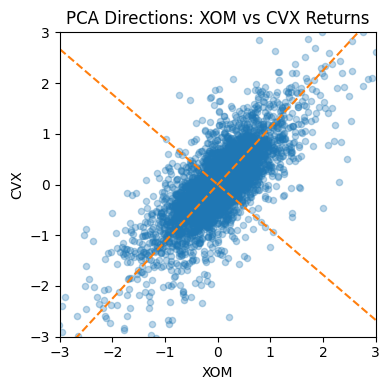

In [6]:
# Visualize PCA directions
def abline(slope, intercept, ax):
    x_vals = np.array(ax.get_xlim())
    return (x_vals, intercept + slope * x_vals)

ax = oil_px.plot.scatter(x='XOM', y='CVX', alpha=0.3, figsize=(4, 4))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.plot(*abline(loadings.loc[0, 'CVX'] / loadings.loc[0, 'XOM'], 0, ax),
        '--', color='C1')
ax.plot(*abline(loadings.loc[1, 'CVX'] / loadings.loc[1, 'XOM'], 0, ax),
        '--', color='C1')
ax.set_title('PCA Directions: XOM vs CVX Returns')
plt.tight_layout()

**Figure: PCA directions for XOM vs CVX.** The dashed lines show the two principal components. The first runs along the **long axis** of the elliptical cloud (direction of maximum spread); the second runs along the **short axis** (perpendicular).

Geometrically, PCA rotates the coordinate system so the new axes align with the directions of maximum variance. Projecting all points onto the PC1 direction yields the maximum possible projected variance.

### Bonus: Connecting PCA to the Covariance Matrix

The eigenvalues of the covariance matrix *are* the explained variances of the principal components.

In [7]:
# Eigendecomposition of covariance matrix
cov_matrix = oil_px.cov()
print("Covariance matrix:")
print(cov_matrix.round(4))

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]

print(f"\nEigenvalues:        {eigenvalues}")
print(f"PCA explained_var_: {pcs.explained_variance_}")
print(f"Match: {np.allclose(eigenvalues, pcs.explained_variance_, atol=0.01)}")
print(f"\nTotal variance = sum(eigenvalues) = {eigenvalues.sum():.4f}")
print(f"  = Var(XOM) + Var(CVX) = {oil_px.var().sum():.4f}")

Covariance matrix:
        XOM     CVX
XOM  0.3943  0.3415
CVX  0.3415  0.4743

Eigenvalues:        [0.77822489 0.0904673 ]
PCA explained_var_: [0.77822489 0.0904673 ]
Match: True

Total variance = sum(eigenvalues) = 0.8687
  = Var(XOM) + Var(CVX) = 0.8687


This confirms a fundamental PCA property: **eigenvalues of the covariance matrix equal the variances of the principal components**, and they sum to the total variance. No information is lost -- only rotated into a coordinate system aligned with maximum variance directions.

$$\text{Explained Variance Ratio}_i = \frac{\lambda_i}{\sum_{j=1}^{p} \lambda_j}$$

---
## Interpreting Principal Components: 16-Stock Analysis

We scale up to 16 major stocks spanning **technology** (AAPL, MSFT, CSCO, INTC), **energy** (CVX, XOM, SLB, COP), **finance** (JPM, WFC, USB, AXP), and **consumer** (WMT, TGT, HD, COST).

In [8]:
# PCA on 16 stocks
syms = sorted(['AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM', 'SLB', 'COP',
        'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST'])
top_sp = sp500_px.loc[sp500_px.index >= '2011-01-01', syms]

sp_pca = PCA()
sp_pca.fit(top_sp)

print(f"Shape: {top_sp.shape} ({top_sp.shape[0]} days, {top_sp.shape[1]} stocks)")
print(f"Variance explained by first 5 PCs: {sp_pca.explained_variance_ratio_[:5].sum():.1%}")

# Cumulative variance
cumvar = np.cumsum(sp_pca.explained_variance_ratio_)
for i in range(min(8, len(cumvar))):
    print(f"  PC1..{i+1}: {cumvar[i]:.1%}")

Shape: (1131, 16) (1131 days, 16 stocks)
Variance explained by first 5 PCs: 80.9%
  PC1..1: 44.5%
  PC1..2: 58.8%
  PC1..3: 69.3%
  PC1..4: 75.5%
  PC1..5: 80.9%
  PC1..6: 85.0%
  PC1..7: 87.9%
  PC1..8: 90.3%


With 16 stocks, the first 5 components already explain a substantial fraction of total variance -- a significant dimensionality reduction from 16 to 5.

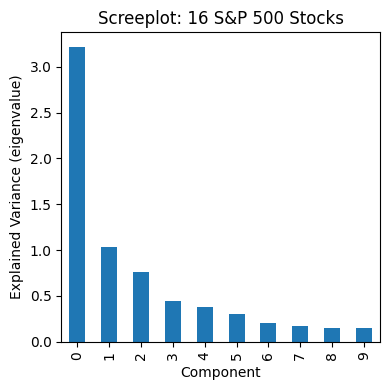

In [9]:
# Screeplot
explained_variance = pd.DataFrame(sp_pca.explained_variance_)
ax = explained_variance.head(10).plot.bar(legend=False, figsize=(4, 4))
ax.set_xlabel('Component')
ax.set_ylabel('Explained Variance (eigenvalue)')
ax.set_title('Screeplot: 16 S&P 500 Stocks')
plt.tight_layout()

**Figure: Screeplot.** The first component has the largest eigenvalue. The "elbow" -- where variance drops sharply then levels off -- suggests how many components to retain. A common threshold: retain enough to explain 80% of variance.

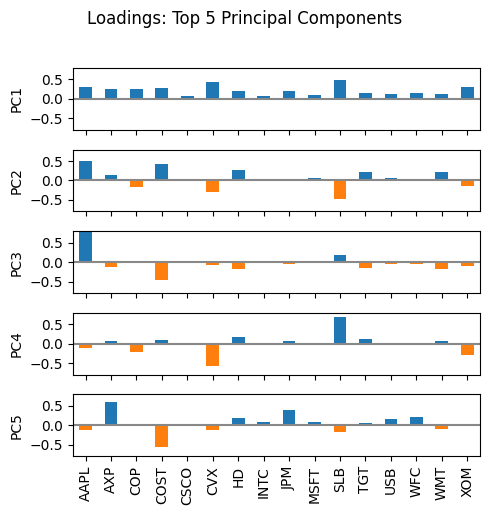

In [10]:
# Loadings for top 5 PCs
loadings = pd.DataFrame(sp_pca.components_[0:5, :], columns=top_sp.columns)

maxPC = 1.01 * loadings.loc[0:5, :].abs().to_numpy().max()
f, axes = plt.subplots(5, 1, figsize=(5, 5), sharex=True)
for i, ax in enumerate(axes):
    pc_loadings = loadings.loc[i, :]
    colors = ['C0' if l > 0 else 'C1' for l in pc_loadings]
    ax.axhline(color='#888888')
    pc_loadings.plot.bar(ax=ax, color=colors)
    ax.set_ylabel(f'PC{i+1}')
    ax.set_ylim(-maxPC, maxPC)
f.suptitle('Loadings: Top 5 Principal Components', y=1.02)
plt.tight_layout()

**Figure: Component loadings for the top 5 PCs.** Blue = positive; orange = negative.

**PC1 ("The Market")**: All loadings share the same sign -- this captures **overall market movement**. On up-market days, PC1 is high; on down-market days, PC1 is low. This is the well-known "market factor" in finance.

**PC2 ("Energy vs. Non-Energy")**: Energy stocks (CVX, XOM, SLB, COP) load opposite to the rest, capturing days when oil prices spike or crash.

**PC3--PC5** pick up increasingly specific contrasts: individual companies or sub-sectors that deviate from broader patterns.

PCA automatically discovers the sector structure of the market from covariance alone -- no labels or domain knowledge were provided.

---
## Correspondence Analysis

PCA requires numeric data. For **categorical** data, **Correspondence Analysis (CA)** reveals associations between categories using a contingency table.

In [11]:
# Correspondence Analysis on household tasks
print("House tasks contingency table:")
print(housetasks)

House tasks contingency table:
           Wife  Alternating  Husband  Jointly
Task                                          
Laundry     156           14        2        4
Main_meal   124           20        5        4
Dinner       77           11        7       13
Breakfast    82           36       15        7
Tidying      53           11        1       57
Dishes       32           24        4       53
Shopping     33           23        9       55
Official     12           46       23       15
Driving      10           51       75        3
Finances     13           13       21       66
Insurance     8            1       53       77
Repairs       0            3      160        2
Holidays      0            1        6      153


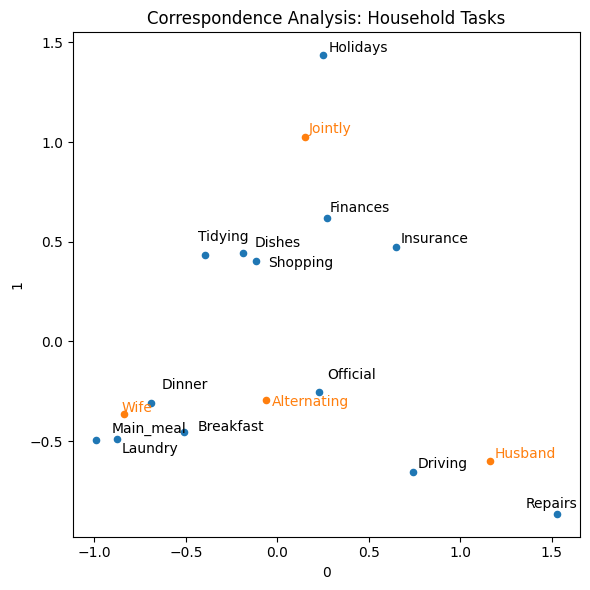

In [12]:
# Fit and plot CA
ca = prince.CA(n_components=2)
ca = ca.fit(housetasks)

ax = ca.row_coordinates(housetasks).plot.scatter(x=0, y=1, figsize=(6, 6))
ca.column_coordinates(housetasks).plot.scatter(x=0, y=1, ax=ax, c='C1')
texts = []
for idx, row in ca.row_coordinates(housetasks).iterrows():
    texts.append(plt.text(row[0], row[1], idx))
for idx, row in ca.column_coordinates(housetasks).iterrows():
    texts.append(plt.text(row[0], row[1], idx, color='C1'))
adjust_text(texts, only_move={'points':'y', 'texts':'y'})
ax.set_title('Correspondence Analysis: Household Tasks')
plt.tight_layout()

**Figure: CA biplot.** Black = tasks; orange = performers. The horizontal axis separates wife-dominant tasks (left) from husband-dominant tasks (right). The vertical axis separates solo tasks (top) from joint tasks (bottom). Tasks near a performer point are strongly associated with that performer.

CA is useful for **exploratory analysis of low-dimensional categorical data** but is not typically used as a preprocessing step for large-scale pipelines.

---

# K-Means Clustering

K-Means partitions $n$ records into $K$ clusters by minimizing the **within-cluster sum of squares (WCSS)**:

$$\text{WCSS} = \sum_{k=1}^{K} \sum_{i \in C_k} \| \mathbf{x}_i - \boldsymbol{\mu}_k \|^2$$

where $\boldsymbol{\mu}_k = \frac{1}{|C_k|} \sum_{i \in C_k} \mathbf{x}_i$ is the centroid of cluster $k$.

**The Algorithm:**
1. Initialize $K$ centers (randomly or via K-Means++)
2. **Assign** each record to the nearest center
3. **Update** each center to the mean of its assigned records
4. Repeat until convergence

**Intuition:** Throw $K$ darts at the data, assign each point to the nearest dart, move each dart to the center of its points, repeat.

## Simple Example: XOM and CVX

In [13]:
# K-Means on XOM/CVX returns
df = sp500_px.loc[sp500_px.index >= '2011-01-01', ['XOM', 'CVX']]
kmeans = KMeans(n_clusters=4, n_init='auto').fit(df)
df['cluster'] = kmeans.labels_
print("First 10 records with cluster assignments:")
print(df.head(10))

First 10 records with cluster assignments:
                 XOM       CVX  cluster
2011-01-03  0.736805  0.240681        3
2011-01-04  0.168668 -0.584516        1
2011-01-05  0.026631  0.446985        3
2011-01-06  0.248558 -0.919751        1
2011-01-07  0.337329  0.180511        3
2011-01-10  0.000000 -0.464168        1
2011-01-11  0.594773  0.825197        3
2011-01-12  0.568137  0.077359        3
2011-01-13  0.053260  0.146127        3
2011-01-14  1.038624  0.610301        3


In [14]:
# Cluster centers and sizes
centers = pd.DataFrame(kmeans.cluster_centers_, columns=['XOM', 'CVX'])
print("Cluster centers:")
print(centers)
print(f"\nCluster sizes: {dict(Counter(kmeans.labels_))}")

Cluster centers:
        XOM       CVX
0 -1.123045 -1.718845
1 -0.286422 -0.492965
2  1.092072  1.581077
3  0.325846  0.449970

Cluster sizes: {np.int32(3): 469, np.int32(1): 421, np.int32(2): 123, np.int32(0): 118}


Two clusters have positive means (up-market days), two have negative means (down-market days). The magnitudes separate mild from extreme movements.

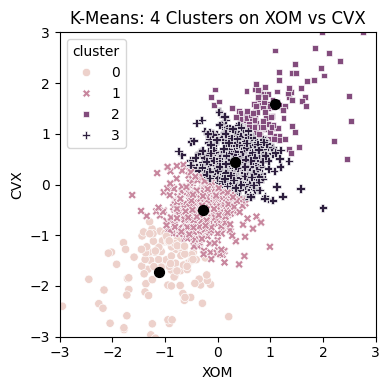

In [15]:
# Visualize clusters
fig, ax = plt.subplots(figsize=(4, 4))
ax = sns.scatterplot(x='XOM', y='CVX', hue='cluster', style='cluster',
                     ax=ax, data=df)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
centers.plot.scatter(x='XOM', y='CVX', ax=ax, s=50, color='black')
ax.set_title('K-Means: 4 Clusters on XOM vs CVX')
plt.tight_layout()

**Figure: K-Means clusters of XOM and CVX returns.** Black dots = centroids. K-Means produces **Voronoi regions** (convex clusters with linear boundaries). Every record is assigned to a cluster, even when clusters are not well-separated -- useful for partitioning data into regime-based groups.

## Interpreting Clusters: 16 Stocks with K=5

In [16]:
# K-Means K=5 on 16 stocks
syms = sorted(['AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM', 'SLB', 'COP',
               'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST'])
top_sp = sp500_px.loc[sp500_px.index >= '2011-01-01', syms]
kmeans = KMeans(n_clusters=5, n_init='auto').fit(top_sp)
print(f"Cluster sizes: {Counter(kmeans.labels_)}")

Cluster sizes: Counter({np.int32(4): 300, np.int32(2): 292, np.int32(0): 278, np.int32(3): 152, np.int32(1): 109})


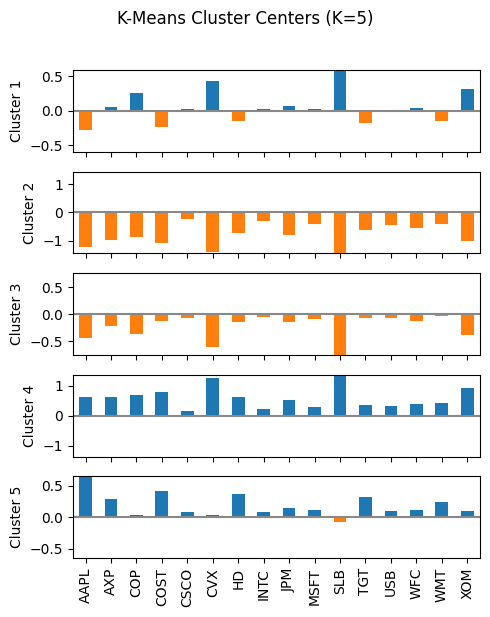

In [17]:
# Visualize cluster centers
centers = pd.DataFrame(kmeans.cluster_centers_, columns=syms)
f, axes = plt.subplots(5, 1, figsize=(5, 6), sharex=True)
for i, ax in enumerate(axes):
    center = centers.loc[i, :]
    maxPC = 1.01 * np.max(np.max(np.abs(center)))
    colors = ['C0' if l > 0 else 'C1' for l in center]
    ax.axhline(color='#888888')
    center.plot.bar(ax=ax, color=colors)
    ax.set_ylabel(f'Cluster {i + 1}')
    ax.set_ylim(-maxPC, maxPC)
f.suptitle('K-Means Cluster Centers (K=5)', y=1.02)
plt.tight_layout()

**Figure: Cluster center profiles.** Each subplot shows mean return per stock within a cluster. Unlike PCA loadings, the **sign of cluster means is meaningful** -- positive means up, negative means down. Some clusters capture broad market moves; others capture sector rotations (energy up while consumer is down, or vice versa).

## Selecting K: The Elbow Method

Plot average within-cluster distance against $K$. The "elbow" marks diminishing returns from additional clusters.

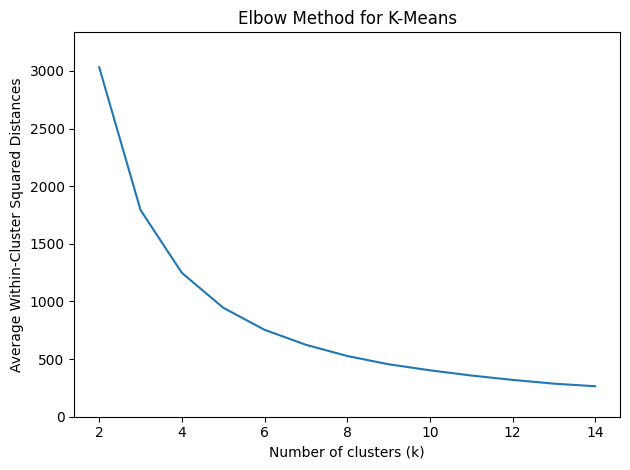

In [18]:
# Elbow method
inertia = []
for n_clusters in range(2, 15):
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init='auto').fit(top_sp)
    inertia.append(kmeans.inertia_ / n_clusters)
inertias = pd.DataFrame({'n_clusters': range(2, 15), 'inertia': inertia})
ax = inertias.plot(x='n_clusters', y='inertia')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Average Within-Cluster Squared Distances')
plt.ylim((0, 1.1 * inertias.inertia.max()))
ax.legend().set_visible(False)
plt.title('Elbow Method for K-Means')
plt.tight_layout()

**Figure: Elbow plot.** No dramatic elbow -- typical for noisy data without well-defined natural clusters. In practice, $K$ is often driven by **business requirements** (how many customer segments to manage) rather than a statistical optimum.

---

# Hierarchical Clustering

Hierarchical clustering builds a **dendrogram** (tree) showing how records group at different similarity levels. No need to pre-specify $K$.

**Agglomerative algorithm** (bottom-up):
1. Each record starts as its own cluster
2. Merge the two most similar clusters
3. Repeat until one cluster remains

**Dissimilarity metrics** between clusters $A$ and $B$:

$$D_{\text{complete}}(A, B) = \max\{d(a_i, b_j)\} \quad D_{\text{single}}(A, B) = \min\{d(a_i, b_j)\} \quad D_{\text{average}} = \text{mean of all } d(a_i, b_j)$$

Ward's method minimizes within-cluster variance, similar to K-Means.

## Clustering 18 Companies

In [19]:
# Hierarchical clustering: transpose to cluster companies (not days)
syms1 = ['AAPL', 'AMZN', 'AXP', 'COP', 'COST', 'CSCO', 'CVX', 'GOOGL', 'HD',
         'INTC', 'JPM', 'MSFT', 'SLB', 'TGT', 'USB', 'WFC', 'WMT', 'XOM']
df = sp500_px.loc[sp500_px.index >= '2011-01-01', syms1].transpose()
print(f"Shape: {df.shape} ({df.shape[0]} companies x {df.shape[1]} trading days)")

Z = linkage(df, method='complete')
print(f"Linkage matrix: {Z.shape} ({Z.shape[0]} merges)")

Shape: (18, 1131) (18 companies x 1131 trading days)
Linkage matrix: (17, 4) (17 merges)


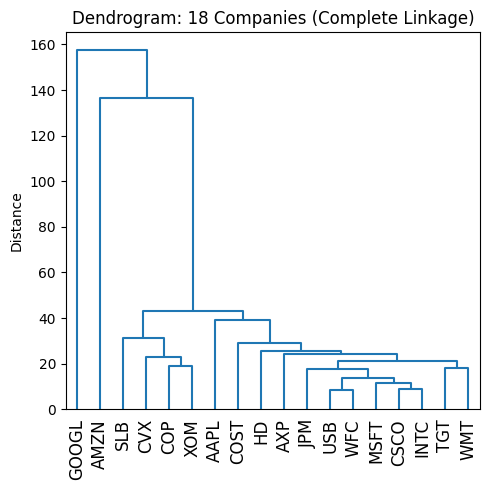

In [20]:
# Dendrogram
fig, ax = plt.subplots(figsize=(5, 5))
dendrogram(Z, labels=list(df.index), color_threshold=0)
plt.xticks(rotation=90)
ax.set_ylabel('Distance')
ax.set_title('Dendrogram: 18 Companies (Complete Linkage)')
plt.tight_layout()

**Figure: Dendrogram.** Height = distance at merge. Oil stocks (SLB, CVX, XOM, COP) merge early -- very similar. GOOGL and AMZN are outliers, each standing apart. AAPL also shows independence. The remaining stocks share broader market correlation.

To extract clusters, cut the tree horizontally.

In [21]:
# Extract 4 clusters
memb = fcluster(Z, 4, criterion='maxclust')
memb = pd.Series(memb, index=df.index)
print("Cluster memberships (4 clusters):")
for key, item in memb.groupby(memb):
    print(f"  Cluster {key}: {', '.join(item.index)}")

Cluster memberships (4 clusters):
  Cluster 1: COP, CVX, SLB, XOM
  Cluster 2: AAPL, AXP, COST, CSCO, HD, INTC, JPM, MSFT, TGT, USB, WFC, WMT
  Cluster 3: AMZN
  Cluster 4: GOOGL


The hierarchy reveals structure at multiple granularities -- a key advantage over K-Means.

## Comparing Linkage Methods

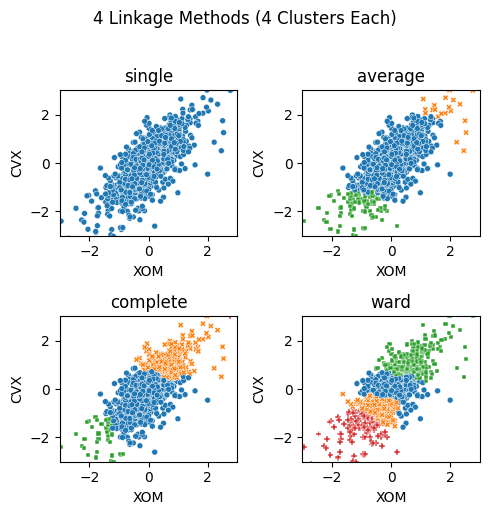

In [22]:
# Compare 4 linkage methods
df = sp500_px.loc[sp500_px.index >= '2011-01-01', ['XOM', 'CVX']]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5, 5))
for i, method in enumerate(['single', 'average', 'complete', 'ward']):
    ax = axes[i // 2, i % 2]
    Z = linkage(df, method=method)
    colors = [f'C{c+1}' for c in fcluster(Z, 4, criterion='maxclust')]
    ax = sns.scatterplot(x='XOM', y='CVX', hue=colors, style=colors,
                         size=0.5, ax=ax, data=df, legend=False)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_title(method)
plt.suptitle('4 Linkage Methods (4 Clusters Each)', y=1.02)
plt.tight_layout()

**Figure: Four linkage methods produce dramatically different clusters.**

- **Single linkage**: "greedy" -- produces one giant cluster plus outlier singletons (chaining effect)
- **Average linkage**: compromise between single and complete
- **Complete linkage**: requires all pairs to be close -- compact clusters
- **Ward's method**: minimizes within-cluster variance -- most similar to K-Means

For most applications, **complete** or **Ward's** give the most interpretable results.

---

# Model-Based Clustering (Gaussian Mixture Models)

Assumes data was generated by a **mixture of $K$ multivariate normal distributions** $\mathcal{N}(\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$:

$$p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

where $\pi_k$ are mixing weights. Parameters are estimated via **Expectation-Maximization (EM)**.

## Multivariate Normal Distribution

Defined by mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$.

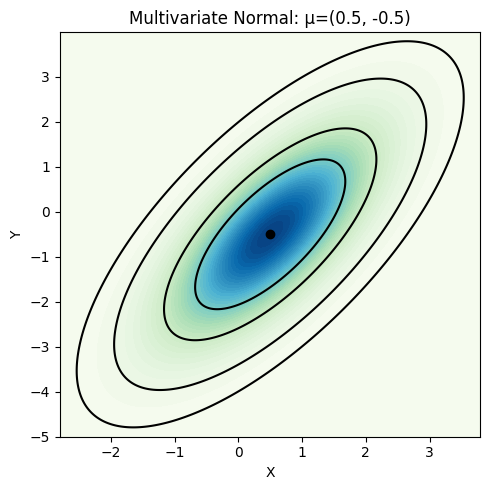

In [23]:
# Visualize 2D normal distribution
mean = [0.5, -0.5]
cov = [[1, 1], [1, 2]]
probability = [.5, .75, .95, .99]

def probLevel(p):
    D = 1
    return (1 - p) / (2 * math.pi * D)
levels = [probLevel(p) for p in probability]

fig, ax = plt.subplots(figsize=(5, 5))
x, y = np.mgrid[-2.8:3.8:.01, -5:4:.01]
pos = np.empty(x.shape + (2,))
pos[:, :, 0] = x; pos[:, :, 1] = y
rv = multivariate_normal(mean, cov)

CS = ax.contourf(x, y, rv.pdf(pos), cmap=cm.GnBu, levels=50)
ax.contour(CS, levels=levels, colors=['black'])
ax.plot(*mean, color='black', marker='o')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Multivariate Normal: μ=(0.5, -0.5)')
plt.tight_layout()

**Figure: Probability contours for a 2D normal.** The elliptical shape reflects positive covariance ($\sigma_{xy} = 1$). Contour lines show 50%, 75%, 95%, and 99% probability regions.

## Gaussian Mixture on Stock Returns

BIC: 4589.93


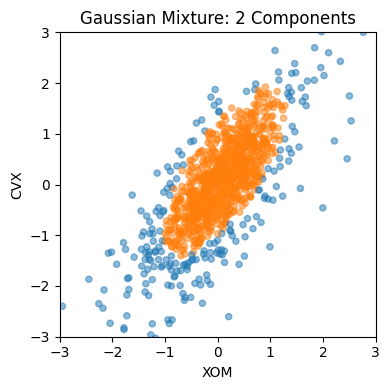

In [24]:
# GMM with 2 components
df = sp500_px.loc[sp500_px.index >= '2011-01-01', ['XOM', 'CVX']]
mclust = GaussianMixture(n_components=2).fit(df)
print(f"BIC: {mclust.bic(df):.2f}")

fig, ax = plt.subplots(figsize=(4, 4))
colors = [f'C{c}' for c in mclust.predict(df)]
df.plot.scatter(x='XOM', y='CVX', c=colors, alpha=0.5, ax=ax)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_title('Gaussian Mixture: 2 Components')
plt.tight_layout()

**Figure: GMM with 2 components.** Unlike K-Means (spatial quadrants), GMM finds a "normal volatility" core and a "high volatility" outer group. This is because GMM models the *shape* (covariance) of each cluster, not just the center.

In [25]:
# GMM parameters
print('Means:')
print(mclust.means_)
print('\nCovariances:')
print(mclust.covariances_)
print(f'\nMixing weights: {mclust.weights_}')

Means:
[[-0.05031426 -0.21161823]
 [ 0.07246995  0.10494619]]

Covariances:
[[[0.97123064 0.97764343]
  [0.97764343 1.67233845]]

 [[0.26822676 0.27562091]
  [0.27562091 0.51679853]]]

Mixing weights: [0.34507118 0.65492882]


The two components have similar means (near zero -- daily returns are roughly centered) but very different covariances. The second component has much larger variances, capturing the **heavy tails** of stock return distributions. Stock returns are **leptokurtic** (heavier tails than Gaussian), so the GMM fits a wide-variance component for extreme days.

## Selecting Components with BIC

$$\text{BIC} = -2 \ln(\hat{L}) + k \ln(n)$$

Lower BIC = better balance of fit and parsimony. We test 4 covariance types across 1--8 components.

Best: full with 2 components (BIC=4589.3)


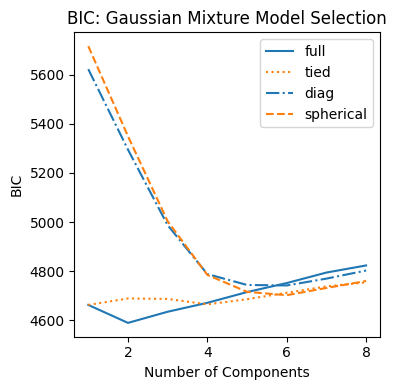

In [26]:
# BIC across models
results = []
covariance_types = ['full', 'tied', 'diag', 'spherical']
for n_components in range(1, 9):
    for covariance_type in covariance_types:
        mclust = GaussianMixture(n_components=n_components, warm_start=True,
                                 covariance_type=covariance_type)
        mclust.fit(df)
        results.append({
            'bic': mclust.bic(df),
            'n_components': n_components,
            'covariance_type': covariance_type,
        })

results = pd.DataFrame(results)
styles = ['C0-','C1:','C0-.', 'C1--']

fig, ax = plt.subplots(figsize=(4, 4))
for i, ct in enumerate(covariance_types):
    subset = results.loc[results.covariance_type == ct, :]
    subset.plot(x='n_components', y='bic', ax=ax, label=ct, kind='line', style=styles[i])
ax.set_xlabel('Number of Components')
ax.set_ylabel('BIC')
ax.set_title('BIC: Gaussian Mixture Model Selection')
plt.tight_layout()

best = results.loc[results.bic.idxmin()]
print(f"Best: {best['covariance_type']} with {int(best['n_components'])} components (BIC={best['bic']:.1f})")

**Figure: BIC for different GMM configurations.** Unlike the K-Means elbow plot, BIC can show a clear minimum, providing a more principled answer to "how many clusters?"

---

# Scaling and Categorical Variables

All unsupervised methods are sensitive to variable **scale**. If one variable ranges from 0 to $100{,}000$ and another from 0 to 30, the high-scale variable dominates.

**Standardization (z-score):**

$$z = \frac{x - \bar{x}}{s}$$

This gives every variable mean 0 and standard deviation 1.

## Without Scaling vs. With Scaling

In [27]:
# Without scaling
loan_data['outcome'] = pd.Categorical(loan_data['outcome'],
                                      categories=['paid off', 'default'], ordered=True)
defaults = loan_data.loc[loan_data['outcome'] == 'default',]
columns = ['loan_amnt', 'annual_inc', 'revol_bal', 'open_acc', 'dti', 'revol_util']

df = defaults[columns]
kmeans = KMeans(n_clusters=4, random_state=1, n_init='auto').fit(df)
counts = Counter(kmeans.labels_)
centers = pd.DataFrame(kmeans.cluster_centers_, columns=columns)
centers['size'] = [counts[i] for i in range(4)]
print("UNSCALED cluster centers:")
print(centers.round(1))

UNSCALED cluster centers:
   loan_amnt  annual_inc  revol_bal  open_acc   dti  revol_util   size
0    17809.8     78669.5    18933.4      11.6  17.0        62.2   7906
1    21444.3    148736.1    33152.7      12.4  13.8        63.2   1654
2    24290.9    409746.5    84711.0      13.4   8.1        60.0     88
3    10274.2     41241.2     9950.1       9.5  17.7        57.9  13023


Without scaling, `annual_inc` and `revol_bal` dominate. One cluster has very few members -- high-income outliers isolated by sheer numeric magnitude, not meaningful borrower differences.

In [28]:
# With StandardScaler
scaler = preprocessing.StandardScaler()
df0 = scaler.fit_transform(df * 1.0)
kmeans = KMeans(n_clusters=4, random_state=1, n_init='auto').fit(df0)
counts = Counter(kmeans.labels_)
centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=columns)
centers['size'] = [counts[i] for i in range(4)]
print("SCALED cluster centers (inverse-transformed):")
print(centers.round(1))

SCALED cluster centers (inverse-transformed):
   loan_amnt  annual_inc  revol_bal  open_acc   dti  revol_util  size
0    13484.7     55908.0    16435.8      14.3  24.2        59.5  6244
1    25950.2    116834.1    32946.0      12.4  16.2        66.1  3670
2    10507.3     51118.0    11635.3       7.5  15.9        77.8  7397
3    10324.8     53456.8     6054.8       8.7  11.3        31.0  5360


After scaling, clusters are balanced and differentiated across *all* variables. Each cluster now tells a meaningful story about borrower segments -- high-DTI vs. low-DTI, high utilization vs. low utilization.

**Rule:** Always standardize before PCA, K-Means, or hierarchical clustering, unless variables are already on comparable scales.

## Dominant Variables in PCA

Even with the same unit (stock returns), high-variance stocks can dominate PCA.

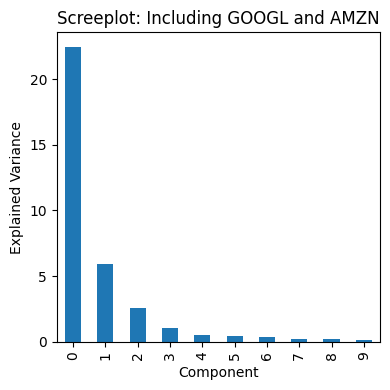

In [29]:
# PCA with GOOGL and AMZN
syms = ['GOOGL', 'AMZN', 'AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM',
        'SLB', 'COP', 'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST']
top_sp1 = sp500_px.loc[sp500_px.index >= '2005-01-01', syms]

sp_pca1 = PCA()
sp_pca1.fit(top_sp1)

explained_variance = pd.DataFrame(sp_pca1.explained_variance_)
ax = explained_variance.head(10).plot.bar(legend=False, figsize=(4, 4))
ax.set_xlabel('Component')
ax.set_ylabel('Explained Variance')
ax.set_title('Screeplot: Including GOOGL and AMZN')
plt.tight_layout()

In [30]:
# Loadings dominated by GOOGL/AMZN
loadings = pd.DataFrame(sp_pca1.components_[0:2, :], columns=top_sp1.columns)
print("Top 2 PC loadings:")
print(loadings.transpose().round(3))

Top 2 PC loadings:
           0      1
GOOGL  0.857 -0.478
AMZN   0.445  0.874
AAPL   0.072  0.021
MSFT   0.036  0.006
CSCO   0.029  0.003
INTC   0.027  0.006
CVX    0.090  0.037
XOM    0.080  0.021
SLB    0.110  0.030
COP    0.058  0.024
JPM    0.071  0.009
WFC    0.053  0.009
USB    0.042  0.006
AXP    0.079  0.024
WMT    0.040  0.007
TGT    0.064  0.025
HD     0.051  0.033
COST   0.071  0.034


GOOGL and AMZN dominate the first two PCs almost entirely. Their much larger variance swallows the components, hiding relationships among the other 16 stocks. Solutions: standardize all stocks, exclude dominant variables, or analyze them separately.

## Problems with Clustering Mixed Data

In [31]:
# One-hot encoding + K-Means on mixed data
columns = ['dti', 'payment_inc_ratio', 'home_', 'pub_rec_zero']
df = pd.get_dummies(defaults[columns], dtype=int)

scaler = preprocessing.StandardScaler()
df0 = scaler.fit_transform(df * 1.0)
kmeans = KMeans(n_clusters=4, random_state=1, n_init='auto').fit(df0)
centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=df.columns)
print("Cluster centers (mixed data, one-hot encoded):")
print(centers.round(2))

Cluster centers (mixed data, one-hot encoded):
     dti  payment_inc_ratio  pub_rec_zero  home__MORTGAGE  home__OWN  \
0  21.43              12.35          0.94            -0.0       -0.0   
1  12.74               5.92          0.90            -0.0       -0.0   
2  17.34               8.35          0.91             1.0       -0.0   
3  17.20               9.27          0.92             0.0        1.0   

   home__RENT  
0         1.0  
1         1.0  
2         0.0  
3         0.0  


Clusters are essentially defined by categorical variable levels (MORTGAGE/OWN/RENT). Standardized binary variables take only two values, and K-Means exploits this to minimize WCSS by grouping records with the same category.

**Solutions for mixed data:**
1. Use **hierarchical clustering with Gower's distance** (handles mixed types natively)
2. **Downscale** binary variables relative to continuous ones
3. **Cluster separately** within categorical subgroups

---
# Chapter Summary

| Method | Best For | Scales To | Key Advantage |
|---|---|---|---|
| **PCA** | Dimension reduction | Very large data | Reveals variable covariance structure |
| **K-Means** | Large-scale clustering | Millions of records | Simple, fast, interpretable |
| **Hierarchical** | Small-medium data | Thousands of records | Dendrogram, no pre-specified $K$ |
| **GMM** | Statistical clustering | Moderate data | BIC model selection, flexible cluster shapes |

**When clusters are well-separated**, all methods agree. **With noisy data**, results diverge. The choice depends on data size, data type, analytical goal, and interpretability needs. **Always scale** unless variables are already comparable.

Unsupervised learning discovers structure -- it is up to the data scientist to determine whether that structure is meaningful.